# Desafío - Clasificación de calidad de ramen

Notebook desarrollado con una estructura equivalente al desafío anterior, adaptado a un problema de clasificación binaria.

## 1. Objetivo del análisis

El objetivo de este trabajo es construir modelos de clasificación que permitan predecir si un ramen será clasificado como **bueno** o **malo** a partir de sus características. Para ello se realizará un análisis de calidad de datos, limpieza, preprocesamiento, entrenamiento de modelos y evaluación comparativa.

En línea con lo solicitado en la pauta, se entrenarán dos modelos:
- **Regresión Logística**
- **Support Vector Machine (SVM)**

## 2. Librerías

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)

pd.set_option("display.max_columns", None)

## 3. Carga de datos

In [2]:
df = pd.read_excel("ramen-ratings.xlsx")
df.head()

,Review #,Brand,Variety,Style,Country,Stars,Top Ten
0,2580,New Touch,T's Restaurant Tantanmen,Cup,Japan,3.75,NaN
1,2579,Just Way,Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...,Pack,Taiwan,1,NaN
2,2578,Nissin,Cup Noodles Chicken Vegetable,Cup,USA,2.25,NaN
3,2577,Wei Lih,GGE Ramen Snack Tomato Flavor,Pack,Taiwan,2.75,NaN
4,2576,Ching's Secret,Singapore Curry,Pack,India,3.75,NaN


In [3]:
df.shape

(2580, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2580 entries, 0 to 2579
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Review #  2580 non-null   int64 
 1   Brand     2580 non-null   object
 2   Variety   2580 non-null   object
 3   Style     2578 non-null   object
 4   Country   2580 non-null   object
 5   Stars     2580 non-null   object
 6   Top Ten   41 non-null     object
dtypes: int64(1), object(6)
memory usage: 141.2+ KB


## 4. Análisis de calidad de datos

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Review #,2580.0,NaN,NaN,NaN,1290.5,744.926171,1.0,645.75,1290.5,1935.25,2580.0
Brand,2580,355,Nissin,381,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Variety,2580,2412,Beef,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Style,2578,7,Pack,1531,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,2580,38,Japan,352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Stars,2580.0,43.0,4.0,393.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Top Ten,41,38,\n,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.isnull().sum().sort_values(ascending=False)

Top Ten     2539
Style          2
Review #       0
Variety        0
Brand          0
Country        0
Stars          0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
for col in df.columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(10))


--- Review # ---
Review #
1       1
2580    1
2579    1
2578    1
17      1
18      1
19      1
20      1
21      1
22      1
Name: count, dtype: int64

--- Brand ---
Brand
Nissin           381
Nongshim          98
Maruchan          76
Mama              71
Paldo             66
Myojo             63
Indomie           53
Samyang Foods     52
Ottogi            46
Lucky Me!         34
Name: count, dtype: int64

--- Variety ---
Variety
Beef                               7
Chicken                            7
Yakisoba                           6
Vegetable                          6
Artificial Chicken                 6
Miso Ramen                         5
Instant Noodles Chicken Flavour    4
Curry Flavour Instant Noodles      4
Curry Udon                         4
Spicy Beef                         4
Name: count, dtype: int64

--- Style ---
Style
Pack    1531
Bowl     481
Cup      450
Tray     108
Box        6
NaN        2
Can        1
Bar        1
Name: count, dtype: int64

--- Country ---
C

### Observaciones

- El dataset contiene variables categóricas como `Brand`, `Variety`, `Style`, `Country` y `Top Ten`.
- La variable `Stars`, que representa la calificación, aparece como tipo `object`, por lo que requiere conversión.
- La columna `Top Ten` presenta una gran cantidad de valores faltantes, por lo que no aporta suficiente información estable para el modelado.
- No se observan duplicados completos en la base.

## 5. Limpieza y construcción de la variable objetivo

In [9]:
df_clean = df.copy()

# Conversión de la calificación a formato numérico
df_clean["Stars"] = pd.to_numeric(df_clean["Stars"], errors="coerce")

# Revisión de valores no convertibles
df_clean["Stars"].isnull().sum()

np.int64(3)

In [10]:
df_clean[df_clean["Stars"].isna()].head()

,Review #,Brand,Variety,Style,Country,Stars,Top Ten
32,2548,Ottogi,Plain Instant Noodle No Soup Included,Pack,South Korea,NaN,NaN
122,2458,Samyang Foods,Sari Ramen,Pack,South Korea,NaN,NaN
993,1587,Mi E-Zee,Plain Noodles,Pack,Malaysia,NaN,NaN


In [11]:
# Eliminación de columnas con muy alta proporción de nulos y poca utilidad para el problema
df_clean = df_clean.drop(columns=["Top Ten"])

# Eliminación de filas sin calificación numérica
df_clean = df_clean.dropna(subset=["Stars"]).copy()

# Variable objetivo
df_clean["quality_label"] = np.where(df_clean["Stars"] >= 3.5, 1, 0) #creamos una columna para saber las recetas de buena calidad

df_clean.head()

,Review #,Brand,Variety,Style,Country,Stars,quality_label
0,2580,New Touch,T's Restaurant Tantanmen,Cup,Japan,3.75,1
1,2579,Just Way,Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...,Pack,Taiwan,1.00,0
2,2578,Nissin,Cup Noodles Chicken Vegetable,Cup,USA,2.25,0
3,2577,Wei Lih,GGE Ramen Snack Tomato Flavor,Pack,Taiwan,2.75,0
4,2576,Ching's Secret,Singapore Curry,Pack,India,3.75,1


In [12]:
df_clean["quality_label"].value_counts()

quality_label
1    1818
0     759
Name: count, dtype: int64

In [13]:
(df_clean["quality_label"].value_counts(normalize=True) * 100).round(2)

quality_label
1    70.55
0    29.45
Name: proportion, dtype: float64

### Criterio de la variable objetivo

Como el dataset entrega una puntuación numérica (`Stars`) y el problema exige una clasificación binaria (**bueno / malo**), se construyó la variable objetivo `quality_label` usando el siguiente criterio:

- **1 = Bueno** si `Stars >= 3.5`
- **0 = Malo** si `Stars < 3.5`

Este umbral es razonable, ya que una calificación desde 3.5 en una escala de 0 a 5 representa una evaluación favorable del producto.

## 6. Análisis exploratorio de datos

In [14]:
df_clean[["Stars"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Stars,2577.0,3.654676,1.015331,0.0,3.25,3.75,4.25,5.0


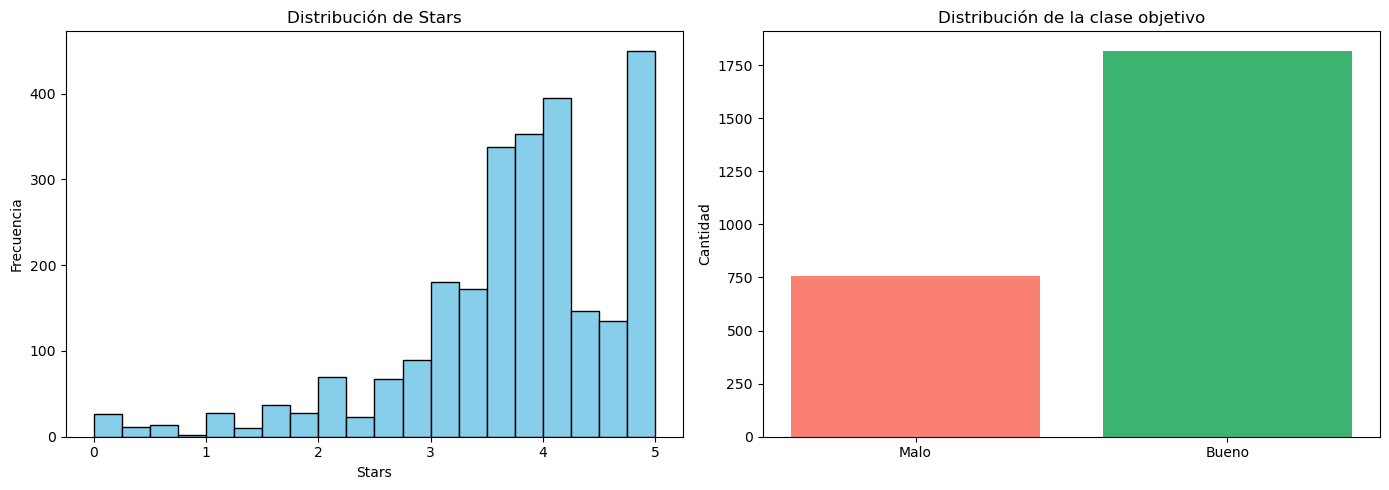

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean["Stars"], bins=20, edgecolor="black", color="skyblue")
axes[0].set_title("Distribución de Stars")
axes[0].set_xlabel("Stars")
axes[0].set_ylabel("Frecuencia")

class_counts = df_clean["quality_label"].value_counts().sort_index()
axes[1].bar(["Malo", "Bueno"], class_counts.values, color=["salmon", "mediumseagreen"])
axes[1].set_title("Distribución de la clase objetivo")
axes[1].set_ylabel("Cantidad")

plt.tight_layout()
plt.show()

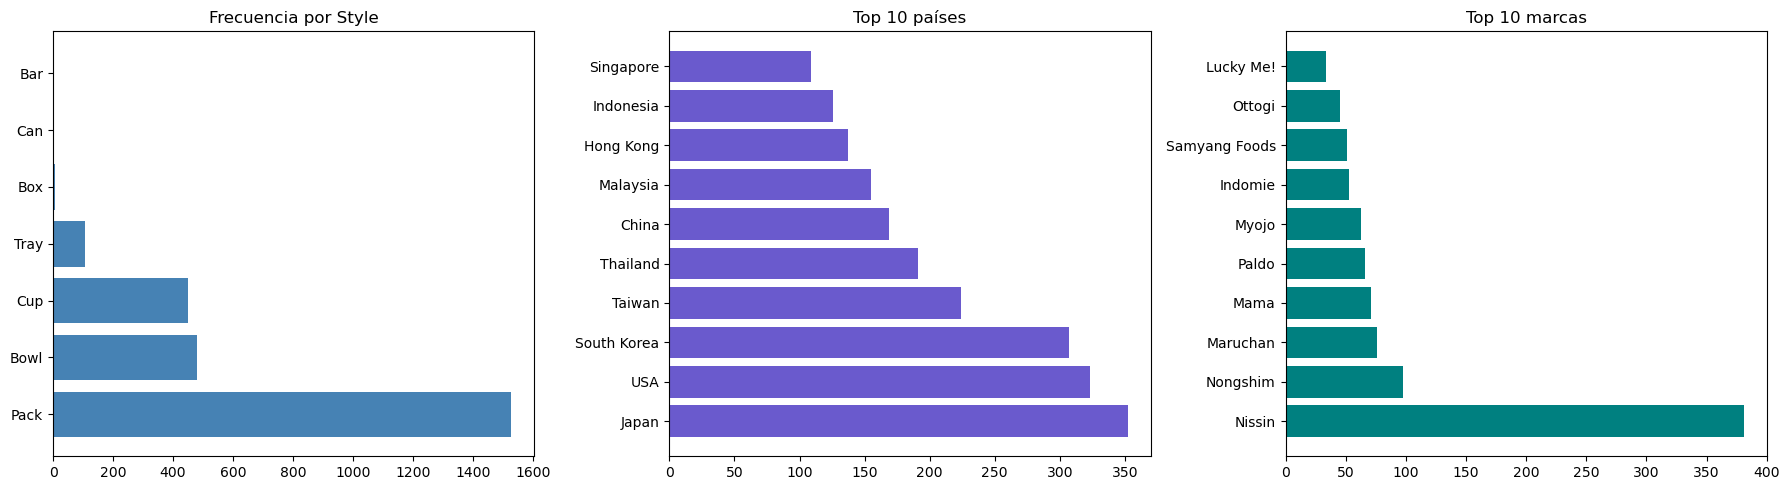

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

style_counts = df_clean["Style"].value_counts()
axes[0].barh(style_counts.index, style_counts.values, color="steelblue")
axes[0].set_title("Frecuencia por Style")

country_counts = df_clean["Country"].value_counts().head(10)
axes[1].barh(country_counts.index, country_counts.values, color="slateblue")
axes[1].set_title("Top 10 países")

brand_counts = df_clean["Brand"].value_counts().head(10)
axes[2].barh(brand_counts.index, brand_counts.values, color="teal")
axes[2].set_title("Top 10 marcas")

plt.tight_layout()
plt.show()

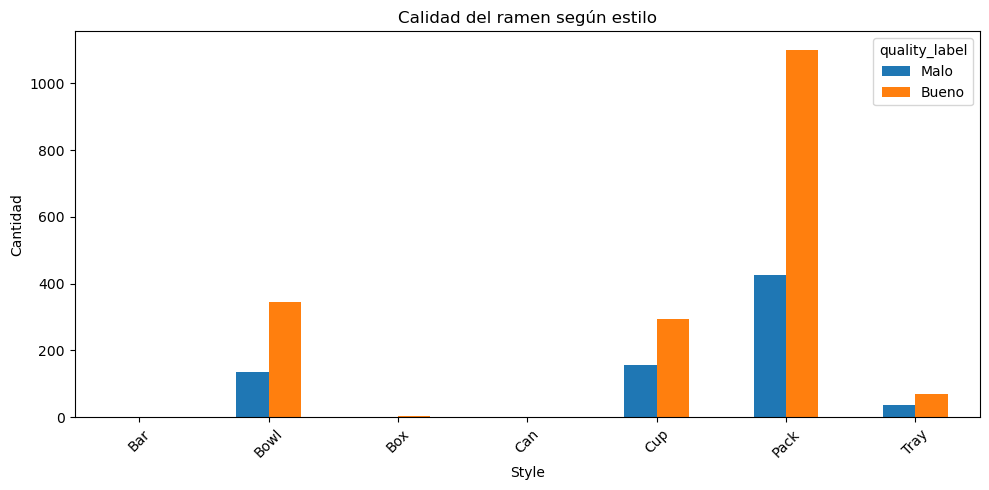

In [17]:
style_quality = pd.crosstab(df_clean["Style"], df_clean["quality_label"])
style_quality.columns = ["Malo", "Bueno"]
style_quality.plot(kind="bar", figsize=(10, 5))
plt.title("Calidad del ramen según estilo")
plt.xlabel("Style")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.legend(title="quality_label")
plt.tight_layout()
plt.show()

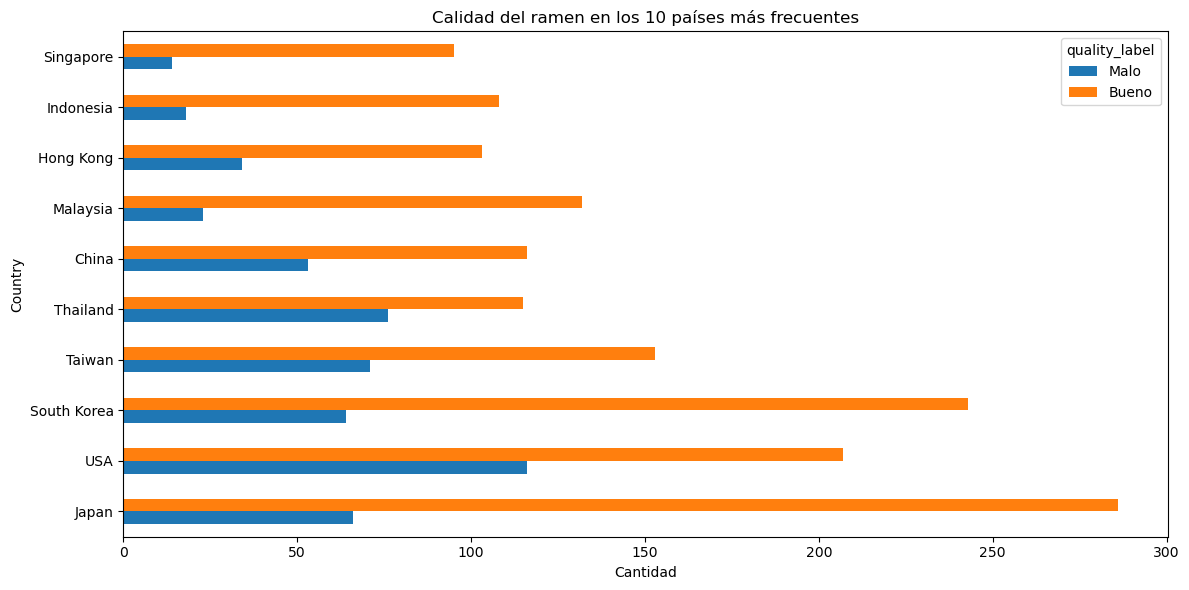

In [18]:
top_countries = df_clean["Country"].value_counts().head(10).index
country_quality = pd.crosstab(
    df_clean.loc[df_clean["Country"].isin(top_countries), "Country"],
    df_clean.loc[df_clean["Country"].isin(top_countries), "quality_label"]
)
country_quality.columns = ["Malo", "Bueno"]
country_quality = country_quality.loc[top_countries]

country_quality.plot(kind="barh", figsize=(12, 6))
plt.title("Calidad del ramen en los 10 países más frecuentes")
plt.xlabel("Cantidad")
plt.ylabel("Country")
plt.legend(title="quality_label")
plt.tight_layout()
plt.show()

### Observaciones

- La variable `Stars` muestra una concentración importante en valores medios y altos.
- La clase objetivo queda relativamente balanceada, aunque con una mayor presencia de observaciones clasificadas como **buenas**.
- Existen estilos, países y marcas con alta frecuencia, lo que hace relevante la codificación de variables categóricas.
- Dado que la mayoría de las variables predictoras son categóricas, será necesario aplicar **One Hot Encoding**.

## 7. Preparación de variables

In [19]:
X = df_clean.drop(columns=["Stars", "quality_label"])
y = df_clean["quality_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2061, 5), (516, 5), (2061,), (516,))

In [20]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include="object").columns.tolist()

num_cols, cat_cols

(['Review #'], ['Brand', 'Variety', 'Style', 'Country'])

In [21]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Review #']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Brand', 'Variety', 'Style', 'Country'])])

### Observaciones

- Las columnas numéricas se imputan con la mediana y luego se escalan.
- Las columnas categóricas se imputan con la categoría más frecuente y luego se codifican con **One Hot Encoding**.
- Se realiza la separación de entrenamiento y prueba antes del ajuste del modelo para evitar **data leakage**.

## 8. Entrenamiento de modelos y búsqueda de hiperparámetros

In [22]:
modelos = {
    "Regresión Logística": {
        "pipeline": Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(max_iter=2000, random_state=42))
        ]),
        "params": {
            "classifier__C": [0.1, 1, 10],
            "classifier__solver": ["liblinear", "lbfgs"]
        }
    },
    "SVM": {
        "pipeline": Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("classifier", SVC(probability=True, random_state=42))
        ]),
        "params": {
            "classifier__C": [0.5, 1, 5],
            "classifier__kernel": ["linear", "rbf"],
            "classifier__gamma": ["scale", "auto"]
        }
    }
}

resultados = []
mejores_modelos = {}

for nombre, config in modelos.items():
    print(f"Entrenando modelo: {nombre}")

    grid = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["params"],
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    mejor_modelo = grid.best_estimator_
    mejores_modelos[nombre] = mejor_modelo

    y_pred = mejor_modelo.predict(X_test)
    y_proba = mejor_modelo.predict_proba(X_test)[:, 1]

    resultados.append({
        "Modelo": nombre,
        "Best Params": grid.best_params_,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_proba)
    })

resultados_df = pd.DataFrame(resultados).sort_values(by="F1", ascending=False)
resultados_df

Entrenando modelo: Regresión Logística
Entrenando modelo: SVM


,Modelo,Best Params,Accuracy,Precision,Recall,F1,ROC_AUC
1,SVM,"{'classifier__C': 1, 'classifier__gamma': 'sca...",0.726744,0.768675,0.876374,0.818999,0.738252
0,Regresión Logística,"{'classifier__C': 1, 'classifier__solver': 'li...",0.722868,0.764988,0.876374,0.816901,0.725889


Se implementó una búsqueda de hiperparámetros mediante GridSearchCV para cada modelo, utilizando validación cruzada de 5 folds y optimizando la métrica F1-score. Posteriormente, se evaluaron los modelos en el conjunto de prueba utilizando múltiples métricas para comparar su rendimiento y seleccionar el modelo más adecuado.

## 9. Evaluación de modelos

In [23]:
resultados_df[["Modelo", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]].round(4)

,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC
1,SVM,0.7267,0.7687,0.8764,0.8190,0.7383
0,Regresión Logística,0.7229,0.7650,0.8764,0.8169,0.7259


In [24]:
mejor_modelo_nombre = resultados_df.iloc[0]["Modelo"]
mejor_modelo = mejores_modelos[mejor_modelo_nombre]

print("Mejor modelo:", mejor_modelo_nombre)
print("Mejores hiperparámetros:", resultados_df.iloc[0]["Best Params"])

Mejor modelo: SVM
Mejores hiperparámetros: {'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}


In [25]:
y_pred_best = mejor_modelo.predict(X_test)
y_proba_best = mejor_modelo.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_best, target_names=["Malo", "Bueno"]))

              precision    recall  f1-score   support

        Malo       0.55      0.37      0.44       152
       Bueno       0.77      0.88      0.82       364

    accuracy                           0.73       516
   macro avg       0.66      0.62      0.63       516
weighted avg       0.71      0.73      0.71       516



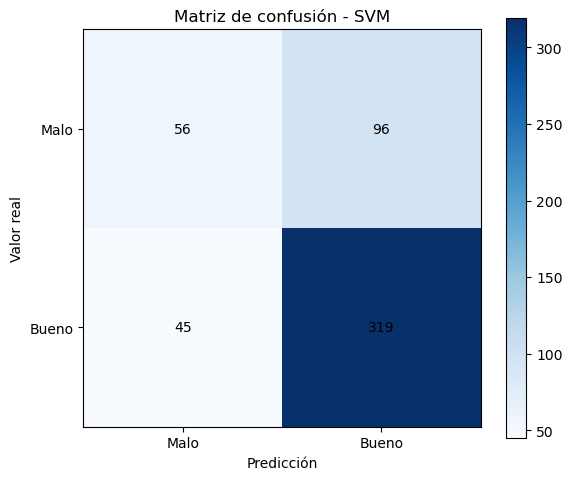

In [26]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title(f"Matriz de confusión - {mejor_modelo_nombre}")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks([0, 1], ["Malo", "Bueno"])
plt.yticks([0, 1], ["Malo", "Bueno"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.colorbar()
plt.tight_layout()
plt.show()

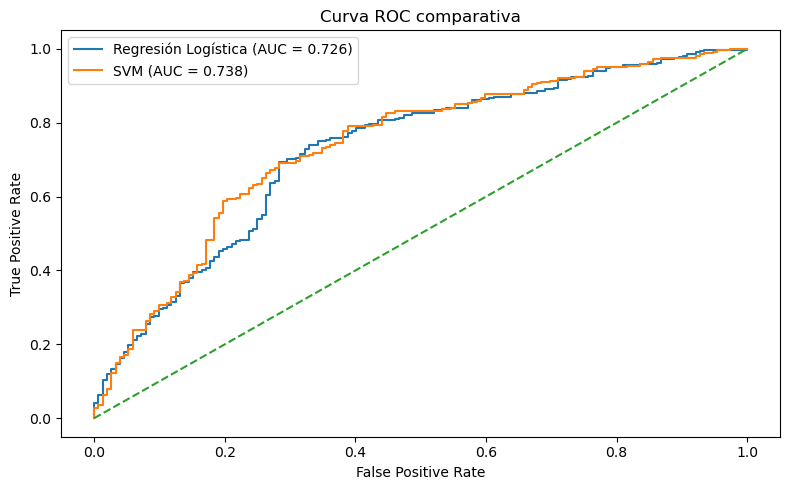

In [27]:
plt.figure(figsize=(8, 5))

for nombre, modelo in mejores_modelos.items():
    y_proba = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Curva ROC comparativa")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

### Observaciones

- Se compararon ambos algoritmos usando métricas relevantes para clasificación binaria.
- El criterio principal de selección fue el **F1-score**, ya que equilibra precisión y recall.
- Además, se utilizó **ROC-AUC** para evaluar la capacidad del modelo de separar correctamente ambas clases.

## 10. Conclusiones

A partir del análisis realizado, se logró construir un flujo completo de clasificación para estimar si un ramen es **bueno** o **malo** en función de sus características.

Principales conclusiones:
- Fue necesario convertir la variable `Stars` a formato numérico y eliminar registros no evaluados.
- La mayoría de las variables predictoras son categóricas, por lo que el uso de **One Hot Encoding** fue clave.
- Se entrenaron dos modelos, **Regresión Logística** y **SVM**, ambos con búsqueda de hiperparámetros mediante `GridSearchCV`.
- Finalmente, se seleccionó el mejor modelo según su desempeño en métricas de clasificación, especialmente **F1-score** y **ROC-AUC**.

En términos prácticos, este enfoque permite automatizar una clasificación inicial de calidad para nuevos productos de ramen a partir de sus atributos registrados.

## 11. Recomendaciones finales

Como mejora futura, se podría:

- Probar otros algoritmos como árboles, Random Forest o XGBoost.
- Evaluar un criterio alternativo para definir la clase objetivo (**bueno / malo**).
- Trabajar reducción de cardinalidad en marcas o variedades muy poco frecuentes.
- Analizar interpretabilidad del modelo para entender qué atributos se asocian con mejor evaluación.